In [1]:
# Cell 1: Imports and Environment Setup

import os
import cv2
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from IPython.display import display

import torchvision.datasets as datasets
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import jaccard_score, classification_report


# ---------------------------------------------------------
# Directory Setup
# Supports both:
# 1. Google Colab - dataset saved locally for speed,
#    models and results saved permanently to Google Drive
# 2. Local VS Code - files saved inside the project folder
# ---------------------------------------------------------

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


if IN_COLAB:
    drive.mount("/content/drive")

    print("Running in Google Colab")

    # Temporary local Colab storage for the dataset
    DATA_DIR = Path("/content/data")

    # Permanent storage in Google Drive
    ROOT_DIR = Path(
        "/content/drive/MyDrive/Digital_image_processing_project"
    )

else:
    print("Running locally / VS Code")

    current_dir = Path.cwd()

    # If the notebook is inside a notebooks folder,
    # use its parent as the project root
    ROOT_DIR = (
        current_dir.parent
        if current_dir.name == "notebooks"
        else current_dir
    )

    DATA_DIR = ROOT_DIR / "data"


RESULTS_DIR = ROOT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
MODELS_DIR = ROOT_DIR / "models"


for directory in [
    DATA_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    MODELS_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ---------------------------------------------------------
# Device
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


print("ROOT_DIR:", ROOT_DIR)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("Using device:", device)

Mounted at /content/drive
Running in Google Colab
ROOT_DIR: /content/drive/MyDrive/Digital_image_processing_project
DATA_DIR: /content/data
RESULTS_DIR: /content/drive/MyDrive/Digital_image_processing_project/results
FIGURES_DIR: /content/drive/MyDrive/Digital_image_processing_project/results/figures
MODELS_DIR: /content/drive/MyDrive/Digital_image_processing_project/models
Using device: cuda


In [ ]:
#Constants and Helper Functions
PASCAL_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow",
    "diningtable", "dog", "horse", "motorbike", "person",
    "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]

VOC_CLASS_TO_ID = {name: i + 1 for i, name in enumerate(PASCAL_CLASSES)}
class_to_idx = {class_name: idx for idx, class_name in enumerate(PASCAL_CLASSES)}

# Helpers for objects and bounding boxes
def get_objects(target):
    objects = target["annotation"].get("object", [])
    if isinstance(objects, dict):
        return [objects]
    return objects

def bbox_area(obj):
    b = obj["bndbox"]
    xmin, ymin = int(float(b["xmin"])), int(float(b["ymin"]))
    xmax, ymax = int(float(b["xmax"])), int(float(b["ymax"]))
    return max(0, xmax - xmin) * max(0, ymax - ymin)

def get_largest_object(target):
    objs = get_objects(target)
    return max(objs, key=bbox_area) if objs else None

def voc_bbox_to_grabcut_rect(obj, width, height, padding=5):
    b = obj["bndbox"]
    xmin = max(0, int(float(b["xmin"])) - padding)
    ymin = max(0, int(float(b["ymin"])) - padding)
    xmax = min(width - 1, int(float(b["xmax"])) + padding)
    ymax = min(height - 1, int(float(b["ymax"])) + padding)
    return (xmin, ymin, max(1, xmax - xmin), max(1, ymax - ymin))

# Deep Learning specific helper
def target_to_multilabel(target):
    y = torch.zeros(len(PASCAL_CLASSES), dtype=torch.float32)
    objects = get_objects(target)
    for obj in objects:
        label = obj["name"]
        if label in class_to_idx:
            y[class_to_idx[label]] = 1.0
    return y

print("Helper functions defined successfully.")

Helper functions defined successfully.


In [ ]:
# Cell 3: Traditional CV Baseline (Canny & GrabCut)
print("Loading PASCAL VOC Validation set for Traditional CV tasks...")

# If the dataset is already downloaded, keep download=False.
# If this is the first run on a new computer/Colab, change temporarily to download=True.
voc_val_cv = datasets.VOCDetection(
    root=str(DATA_DIR),
    year="2012",
    image_set="val",
    download=False
)

SEGMENTATION_DIR = DATA_DIR / "VOCdevkit" / "VOC2012" / "SegmentationClass"


# ---------------------------------------------------------
# CV Algorithms
# ---------------------------------------------------------
def run_canny(image, t1=100, t2=200):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    return (cv2.Canny(gray, t1, t2) > 0).astype(np.uint8)


def run_grabcut(image, grabcut_rect, iterations=5):
    mask = np.zeros(image.shape[:2], np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    cv2.grabCut(
        image,
        mask,
        grabcut_rect,
        bgd_model,
        fgd_model,
        iterations,
        cv2.GC_INIT_WITH_RECT
    )

    return np.where(
        (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
        1,
        0
    ).astype(np.uint8)


def binary_iou(pred, gt, valid):
    p = pred[valid] == 1
    g = gt[valid] == 1

    union = np.logical_or(p, g).sum()

    if union == 0:
        return 0.0

    return float(np.logical_and(p, g).sum()) / union


# ---------------------------------------------------------
# Evaluation on clean images
# ---------------------------------------------------------
NUM_EVAL_IMAGES = 50
metrics_records = []

eval_indices = [
    i for i in range(len(voc_val_cv))
    if (
        SEGMENTATION_DIR /
        f"{Path(voc_val_cv[i][1]['annotation']['filename']).stem}.png"
    ).exists()
][:NUM_EVAL_IMAGES]

print(f"Evaluating Canny and GrabCut on {len(eval_indices)} clean images...")

for sample_idx in eval_indices:
    img, target = voc_val_cv[sample_idx]

    clean_image = np.array(img.convert("RGB")).copy()
    selected_obj = get_largest_object(target)

    if not selected_obj or selected_obj["name"] not in VOC_CLASS_TO_ID:
        continue

    selected_label = selected_obj["name"]

    grabcut_rect = voc_bbox_to_grabcut_rect(
        selected_obj,
        img.size[0],
        img.size[1]
    )

    gt_path = SEGMENTATION_DIR / f"{Path(target['annotation']['filename']).stem}.png"
    gt_seg = np.array(Image.open(gt_path))

    gt_mask = (gt_seg == VOC_CLASS_TO_ID[selected_label]).astype(np.uint8)
    valid_pixels = gt_seg != 255

    clean_edges = run_canny(clean_image)
    clean_grabcut_mask = run_grabcut(clean_image, grabcut_rect)

    metrics_records.append({
        "sample_idx": sample_idx,
        "class": selected_label,
        "canny_edge_density": float(clean_edges.sum()) / clean_edges.size,
        "grabcut_iou": binary_iou(clean_grabcut_mask, gt_mask, valid_pixels)
    })


# ---------------------------------------------------------
# Display metrics only
# ---------------------------------------------------------
metrics_df = pd.DataFrame(metrics_records)

print("\n--- Traditional CV Baseline: Mean Metrics Per Class ---")
display(
    metrics_df
    .groupby("class")[["grabcut_iou", "canny_edge_density"]]
    .mean()
)

print("\n--- Traditional CV Baseline: Overall Mean ---")
cv_baseline_summary = pd.DataFrame({
    "Task / Model": ["Canny", "GrabCut"],
    "Evaluation Metric": ["Mean Edge Density", "Mean IoU"],
    "Baseline Score": [
        metrics_df["canny_edge_density"].mean(),
        metrics_df["grabcut_iou"].mean()
    ]
})

display(cv_baseline_summary)

Loading PASCAL VOC Validation set for Traditional CV tasks...


Evaluating Canny and GrabCut on 50 clean images...

--- Traditional CV Baseline: Mean Metrics Per Class ---


,grabcut_iou,canny_edge_density
class,,
bird,0.833740,0.050251
boat,0.620144,0.066018
bottle,0.963579,0.061519
bus,0.879717,0.058741
car,0.605259,0.057877
cat,0.798608,0.079048
chair,0.914607,0.073739
cow,0.804023,0.161254
dog,0.839664,0.078354



--- Traditional CV Baseline: Overall Mean ---


,Task / Model,Evaluation Metric,Baseline Score
0,Canny,Mean Edge Density,0.096778
1,GrabCut,Mean IoU,0.659603


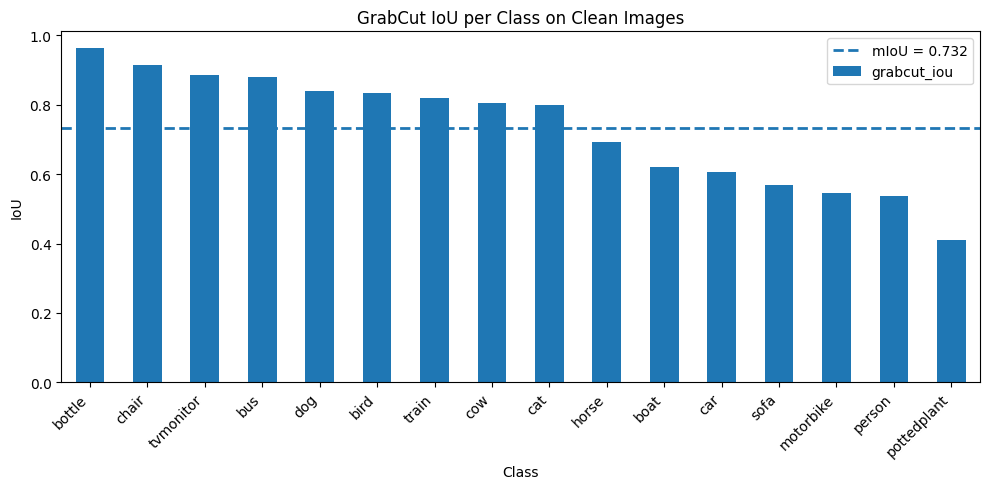

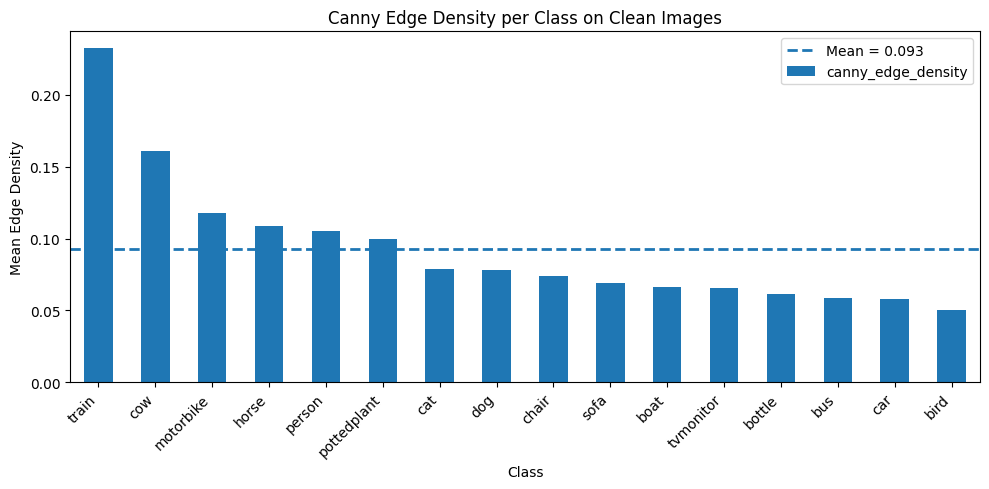

In [ ]:
# Cell 3.5: Traditional CV Per-Class Baseline Plots

# ---------------------------------------------------------
# GrabCut IoU per class + mIoU line
# ---------------------------------------------------------
grabcut_per_class = (
    metrics_df
    .groupby("class")["grabcut_iou"]
    .mean()
    .sort_values(ascending=False)
)

grabcut_miou = grabcut_per_class.mean()

plt.figure(figsize=(10, 5))
ax = grabcut_per_class.plot(kind="bar")

plt.axhline(
    y=grabcut_miou,
    linestyle="--",
    linewidth=2,
    label=f"mIoU = {grabcut_miou:.3f}"
)

plt.title("GrabCut IoU per Class on Clean Images")
plt.ylabel("IoU")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "grabcut_iou_per_class_clean.png", dpi=150, bbox_inches="tight")
plt.show()


# ---------------------------------------------------------
# Canny edge density per class + mean line
# ---------------------------------------------------------
canny_per_class = (
    metrics_df
    .groupby("class")["canny_edge_density"]
    .mean()
    .sort_values(ascending=False)
)

canny_mean = canny_per_class.mean()

plt.figure(figsize=(10, 5))
ax = canny_per_class.plot(kind="bar")

plt.axhline(
    y=canny_mean,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {canny_mean:.3f}"
)

plt.title("Canny Edge Density per Class on Clean Images")
plt.ylabel("Mean Edge Density")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "canny_edge_density_per_class_clean.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#  Deep Learning Dataset Preparation
class VOCMultiLabelDataset(Dataset):
    def __init__(self, dataset, transform=None, max_samples=None):
        self.dataset = dataset
        self.transform = transform
        self.indices = list(range(len(dataset)))[:max_samples] if max_samples else list(range(len(dataset)))

    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        img, target = self.dataset[self.indices[i]]
        return self.transform(img) if self.transform else img, target_to_multilabel(target)

print("Loading Train/Val sets for Deep Learning...")
voc_train = datasets.VOCDetection(root=str(DATA_DIR), year="2012", image_set="train", download=True)
voc_val = datasets.VOCDetection(root=str(DATA_DIR), year="2012", image_set="val", download=True)

weights = ResNet50_Weights.DEFAULT
transform = weights.transforms()

train_loader = DataLoader(VOCMultiLabelDataset(voc_train, transform, 3000), batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(VOCMultiLabelDataset(voc_val, transform, 800), batch_size=32, shuffle=False, num_workers=2)

print(f"DL DataLoaders Ready. Train: {len(train_loader.dataset)}, Val: {len(val_loader.dataset)}")

Loading Train/Val sets for Deep Learning...


/usr/lib64/python3.9/tarfile.py:2288: RuntimeWarning: The default behavior of tarfile extraction has been changed to disallow common exploits (including CVE-2007-4559). By default, absolute/parent paths are disallowed and some mode bits are cleared. See https://access.redhat.com/articles/7004769 for more details.
  warnings.warn(


DL DataLoaders Ready. Train: 3000, Val: 800


Starting Training...
Epoch 1/6 | Train Loss: 0.2052 | Val Loss: 0.1098
Epoch 2/6 | Train Loss: 0.1016 | Val Loss: 0.0848
Epoch 3/6 | Train Loss: 0.0760 | Val Loss: 0.0758
Epoch 4/6 | Train Loss: 0.0626 | Val Loss: 0.0718
Epoch 5/6 | Train Loss: 0.0534 | Val Loss: 0.0713
Epoch 6/6 | Train Loss: 0.0458 | Val Loss: 0.0707


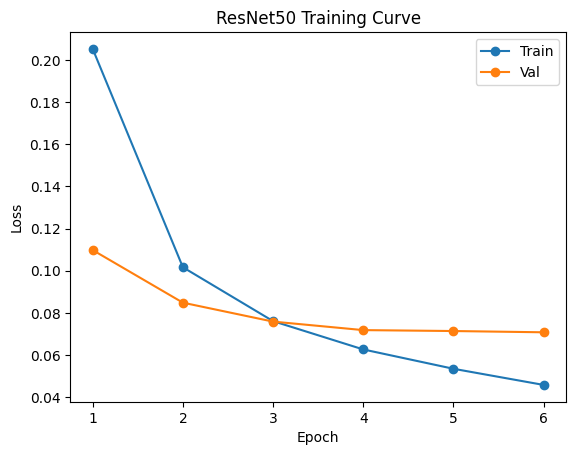

In [ ]:
# Model Definition & Training Loop
model = resnet50(weights=weights)
for param in model.parameters(): param.requires_grad = False
for param in model.layer4.parameters(): param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, len(PASCAL_CLASSES))
model = model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-5},
    {"params": model.fc.parameters(), "lr": 1e-3}
])

def run_epoch(is_train):
    model.train() if is_train else model.eval()
    loader = train_loader if is_train else val_loader
    running_loss = 0.0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if is_train: optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            if is_train: loss.backward(); optimizer.step()
            running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)

num_epochs = 6
train_losses, val_losses = [], []

print("Starting Training...")
for epoch in range(num_epochs):
    t_loss = run_epoch(is_train=True)
    v_loss = run_epoch(is_train=False)
    train_losses.append(t_loss); val_losses.append(v_loss)
    print(f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(range(1, num_epochs + 1), train_losses, marker="o", label="Train")
plt.plot(range(1, num_epochs + 1), val_losses, marker="o", label="Val")
plt.title("ResNet50 Training Curve on Clean Images")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "resnet50_training_curve_clean.png", dpi=150, bbox_inches="tight")
plt.show()


--- Deep Learning: Multi-Label IoU Per Class ---


,Class,IoU (Jaccard)
7,cat,0.941176
14,person,0.908257
18,train,0.882353
2,bird,0.838710
12,horse,0.800000
11,dog,0.770492
0,aeroplane,0.666667
3,boat,0.630435
13,motorbike,0.578947
6,car,0.571429



Generating Unified Visualization focusing on Multi-Label images...


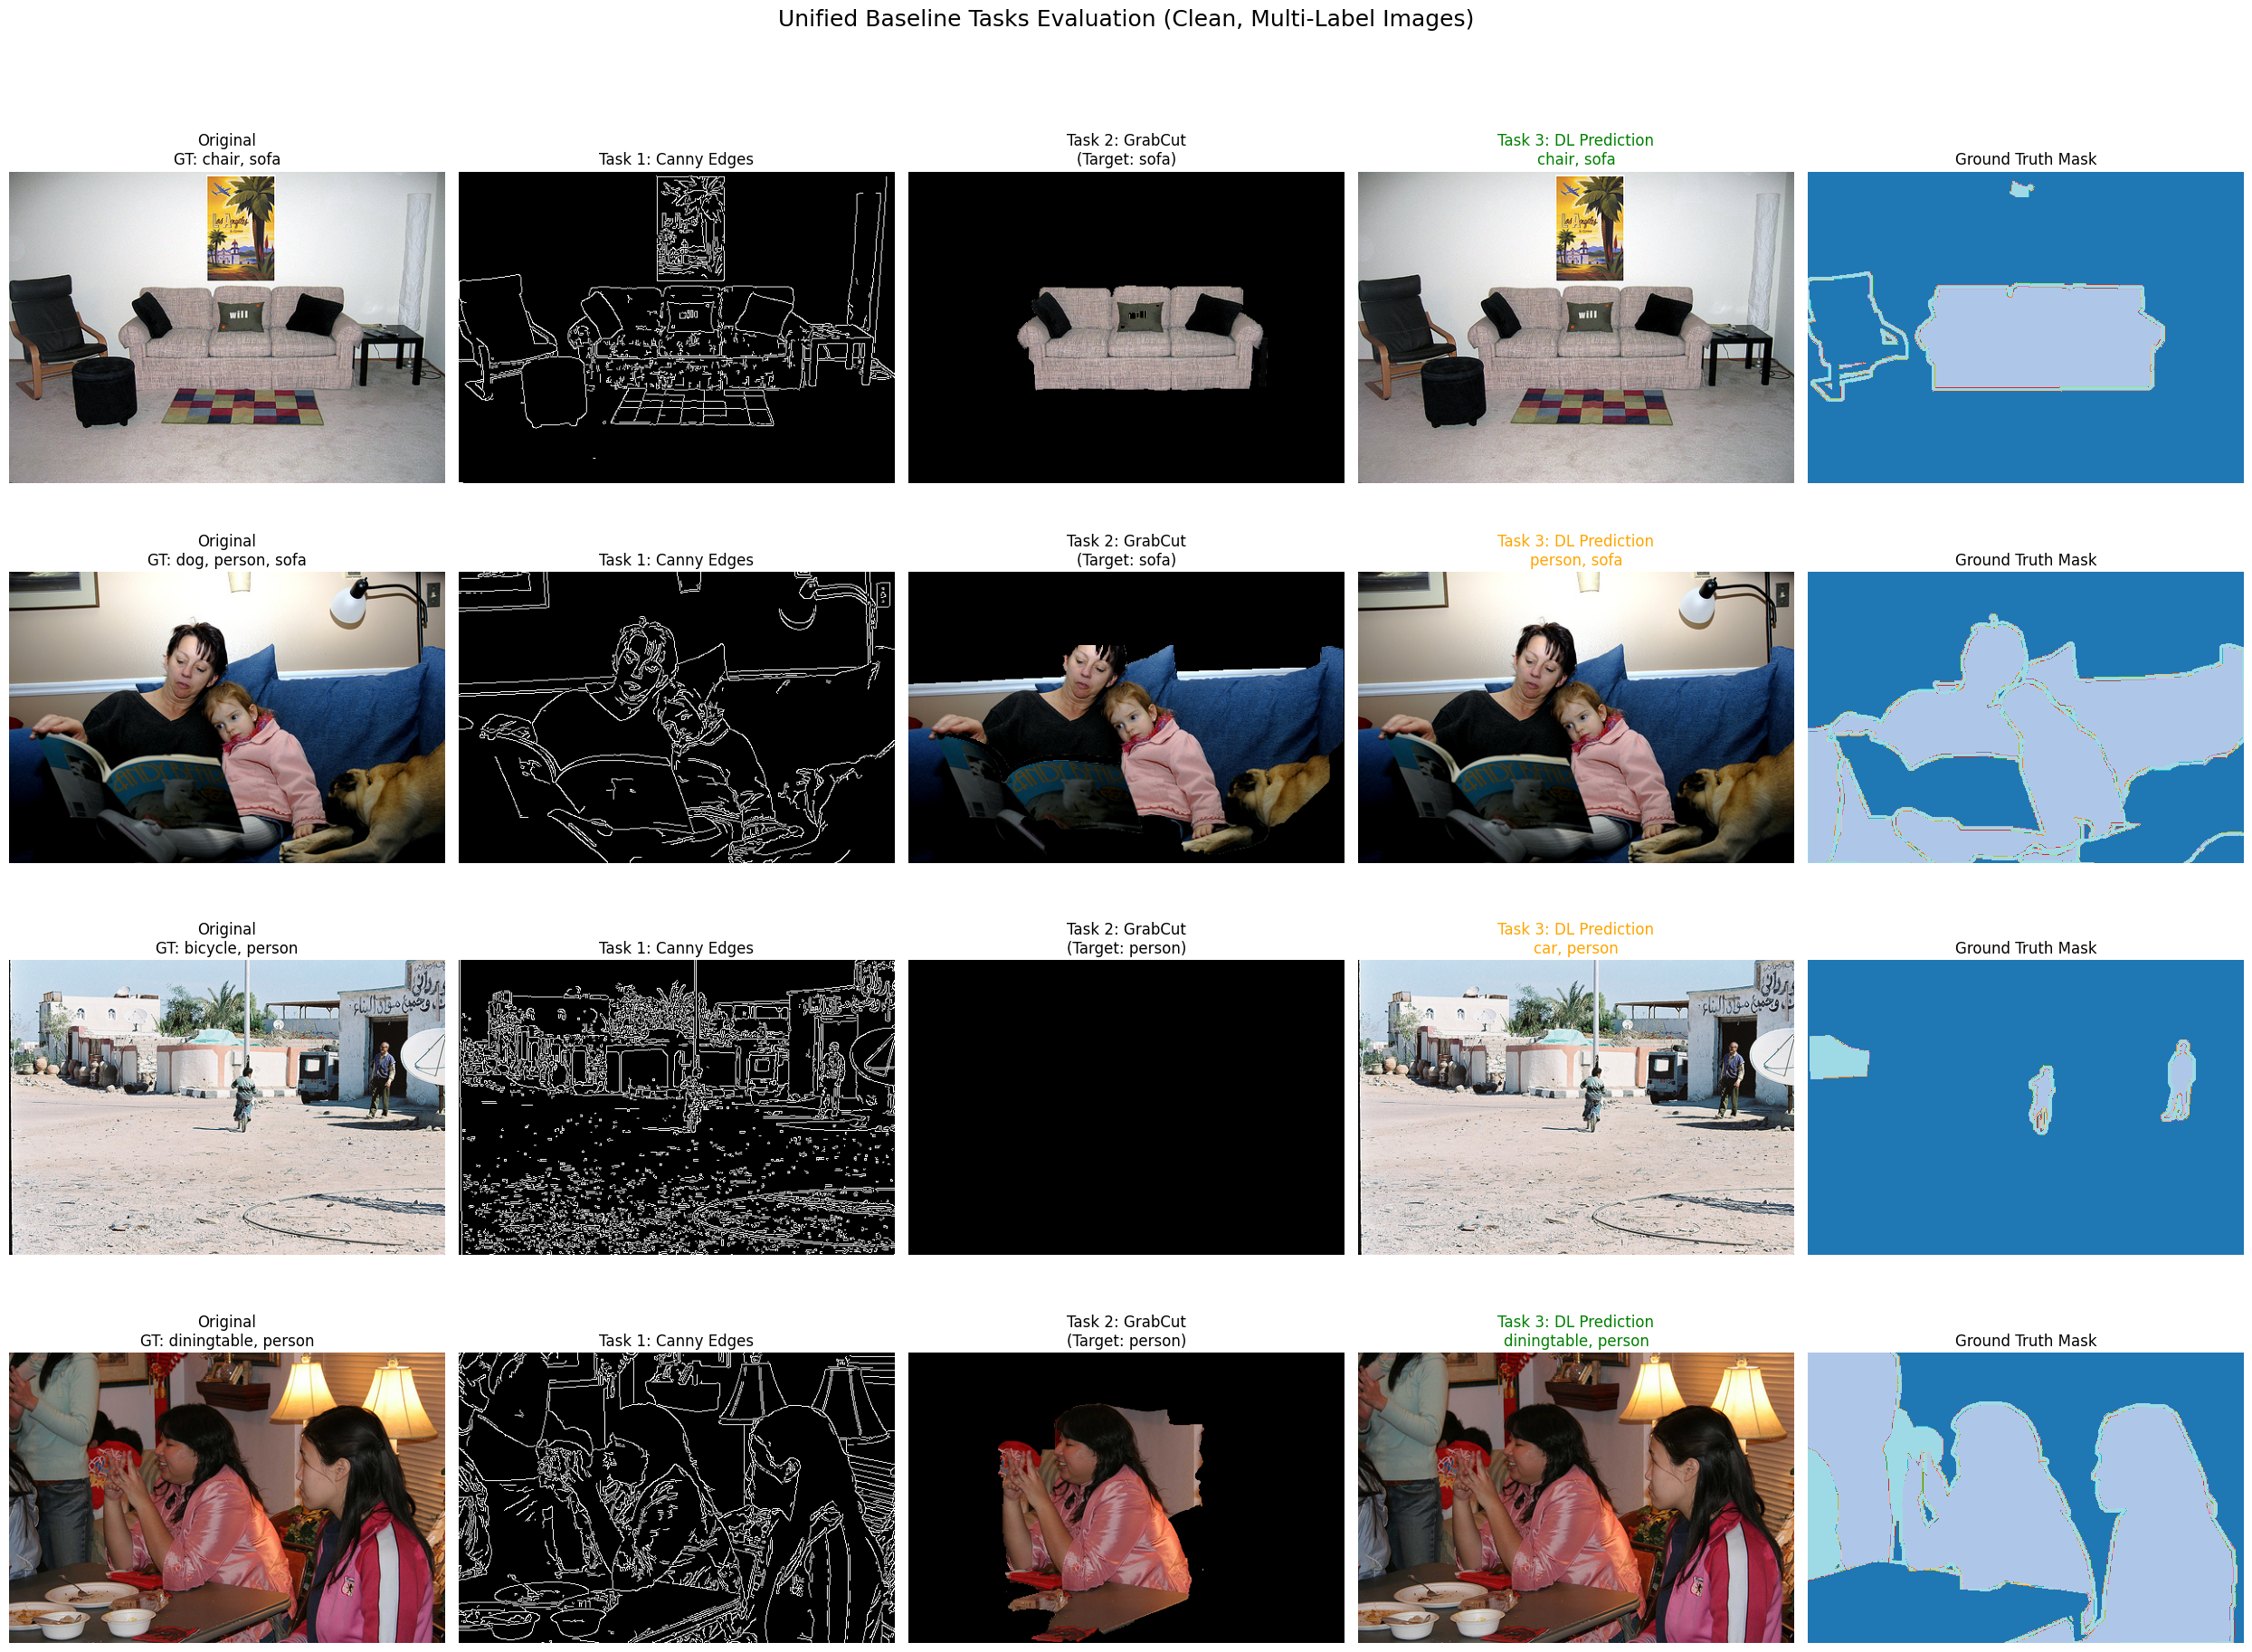

Model saved to /home/dsi/segalte/final_project/drtf-estimation-finel-project/digital image proccesing/models/resnet50_multilabel_clean.pth


In [ ]:
# Cell 6: Unified Visual Output (Multi-Label Focus) & DL Evaluation
model.eval()

# Metrics for Deep Learning (Calculate Jaccard/IoU per class)
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        logits = model(images.to(device))
        probs = torch.sigmoid(logits).cpu().numpy()
        all_preds.append((probs > 0.3).astype(int))
        all_labels.append(labels.numpy())

all_preds = np.vstack(all_preds)
all_labels = np.vstack(all_labels)
ious = jaccard_score(all_labels, all_preds, average=None)
metrics_df_dl = pd.DataFrame({"Class": PASCAL_CLASSES, "IoU (Jaccard)": ious})

print("\n--- Deep Learning: Multi-Label IoU Per Class ---")
display(metrics_df_dl.sort_values(by="IoU (Jaccard)", ascending=False))

# --- UNIFIED VISUALIZATION FOR ALL TASKS ---
print("\nGenerating Unified Visualization focusing on Multi-Label images...")

# Smart selection: Find up to 4 images that have MORE THAN ONE class
vis_indices = []
for idx in eval_indices:
    _, target = voc_val_cv[idx]
    gt_vector = target_to_multilabel(target)
    # If the image has more than 1 unique label, add it to our visualization list
    if gt_vector.sum() > 1:
        vis_indices.append(idx)
    if len(vis_indices) == 4:
        break

# Fallback: If we didn't find 4 multi-label images, fill the rest with standard ones
if len(vis_indices) < 4:
    for idx in eval_indices:
        if idx not in vis_indices:
            vis_indices.append(idx)
        if len(vis_indices) == 4:
            break

fig_vis, axes_vis = plt.subplots(4, 5, figsize=(25, 20))

for row, idx in enumerate(vis_indices):
    img, target = voc_val_cv[idx]
    clean_image = np.array(img.convert("RGB")).copy()
    selected_obj = get_largest_object(target) # For GrabCut

    if not selected_obj or selected_obj["name"] not in VOC_CLASS_TO_ID: continue

    # 1. GrabCut & Canny Preparation
    grabcut_rect = voc_bbox_to_grabcut_rect(selected_obj, img.size[0], img.size[1])
    clean_edges = run_canny(clean_image)
    clean_grabcut_mask = run_grabcut(clean_image, grabcut_rect)

    # 2. Deep Learning Preparation
    input_t = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(input_t))[0].detach().cpu().numpy()

    pred_labels = [PASCAL_CLASSES[i] for i, p in enumerate(probs) if p > 0.3]
    gt_labels = [PASCAL_CLASSES[i] for i, v in enumerate(target_to_multilabel(target)) if v == 1]

    # 3. Plotting
    axes_vis[row, 0].imshow(clean_image)
    axes_vis[row, 0].set_title(f"Original\nGT: {', '.join(gt_labels)}", fontsize=12)

    axes_vis[row, 1].imshow(clean_edges, cmap="gray")
    axes_vis[row, 1].set_title("Task 1: Canny Edges", fontsize=12)

    axes_vis[row, 2].imshow(clean_image * clean_grabcut_mask[:, :, None])
    axes_vis[row, 2].set_title(f"Task 2: GrabCut\n(Target: {selected_obj['name']})", fontsize=12)

    axes_vis[row, 3].imshow(img)

    # Format DL prediction text color based on correct matching
    text_color = 'green' if set(pred_labels) == set(gt_labels) else ('orange' if set(pred_labels).intersection(set(gt_labels)) else 'red')
    axes_vis[row, 3].set_title(f"Task 3: DL Prediction\n{', '.join(pred_labels) if pred_labels else 'None'}", fontsize=12, color=text_color)

    axes_vis[row, 4].imshow(np.array(Image.open(SEGMENTATION_DIR / f"{Path(target['annotation']['filename']).stem}.png")), cmap='tab20')
    axes_vis[row, 4].set_title("Ground Truth Mask", fontsize=12)

    for ax in axes_vis[row]:
        ax.axis("off")

plt.suptitle("Unified Baseline Tasks Evaluation (Clean, Multi-Label Images)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(FIGURES_DIR / "part1_unified_baseline_multilabel_vis.png")
plt.show()

# Save Model locally
torch.save(model.state_dict(), MODELS_DIR / "resnet50_multilabel_clean.pth")
print(f"Model saved to {MODELS_DIR / 'resnet50_multilabel_clean.pth'}")

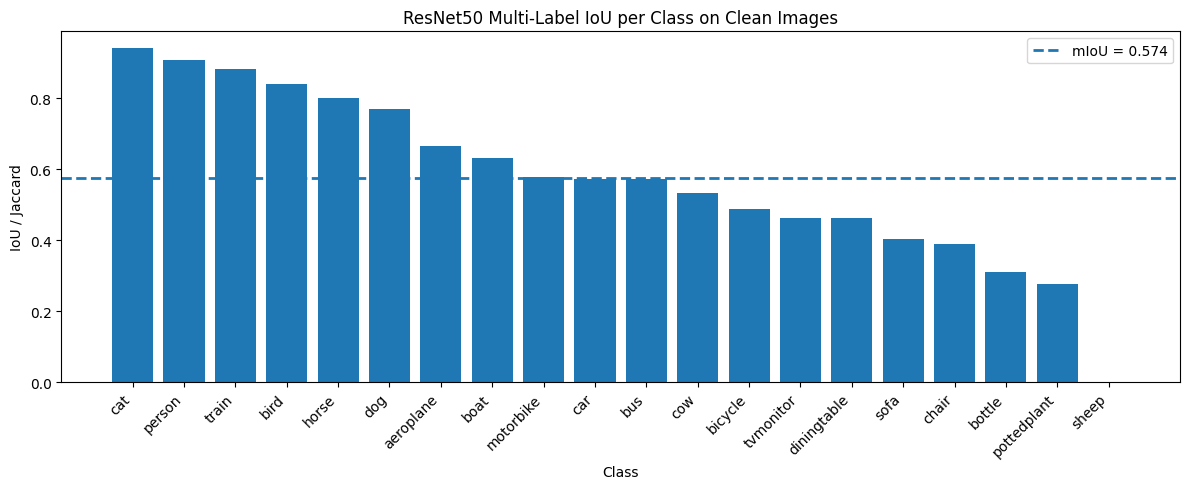

In [ ]:
# Cell 6.5: ResNet50 Per-Class Baseline Plot

resnet_per_class = (
    metrics_df_dl
    .sort_values("IoU (Jaccard)", ascending=False)
)

resnet_miou = resnet_per_class["IoU (Jaccard)"].mean()

plt.figure(figsize=(12, 5))

plt.bar(
    resnet_per_class["Class"],
    resnet_per_class["IoU (Jaccard)"]
)

plt.axhline(
    y=resnet_miou,
    linestyle="--",
    linewidth=2,
    label=f"mIoU = {resnet_miou:.3f}"
)

plt.title("ResNet50 Multi-Label IoU per Class on Clean Images")
plt.ylabel("IoU / Jaccard")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "resnet50_iou_per_class_clean.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
baseline_summary = pd.DataFrame({
    "Task / Model": ["Canny", "GrabCut", "ResNet50"],
    "Evaluation Metric": [
        "Mean Edge Density",
        "Mean IoU",
        "Mean Multi-label IoU / Jaccard"
    ],
    "Baseline Score": [
        metrics_df["canny_edge_density"].mean(),
        metrics_df["grabcut_iou"].mean(),
        metrics_df_dl["IoU (Jaccard)"].mean()
    ]
})

display(baseline_summary)

,Task / Model,Evaluation Metric,Baseline Score
0,Canny,Mean Edge Density,0.096778
1,GrabCut,Mean IoU,0.659603
2,ResNet50,Mean Multi-label IoU / Jaccard,0.574446


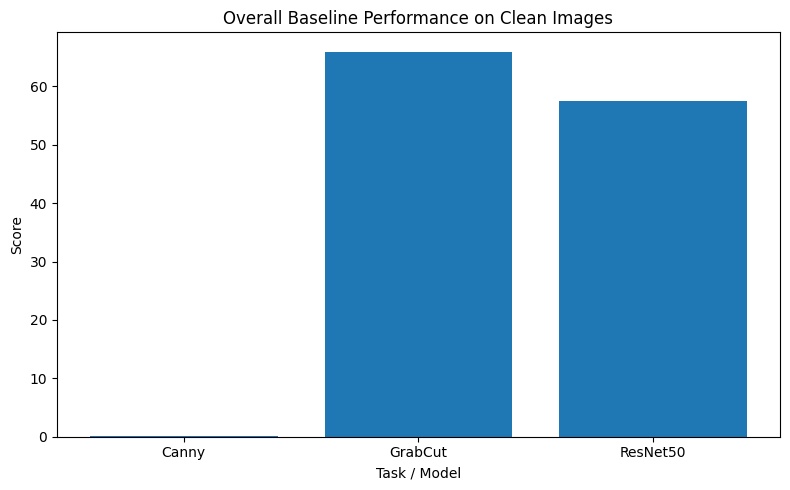

,Task / Model,Evaluation Metric,Baseline Score,Plot Score
0,Canny,Mean Edge Density,0.096778,0.096778
1,GrabCut,Mean IoU,0.659603,65.960258
2,ResNet50,Mean Multi-label IoU / Jaccard,0.574446,57.444595


In [ ]:
# Cell 8: Overall Clean Baseline Summary Plot

baseline_plot_df = baseline_summary.copy()

# Convert IoU/Jaccard scores to percentages for clearer visualization
baseline_plot_df["Plot Score"] = baseline_plot_df["Baseline Score"]
baseline_plot_df.loc[
    baseline_plot_df["Task / Model"].isin(["GrabCut", "ResNet50"]),
    "Plot Score"
] *= 100

plt.figure(figsize=(8, 5))
plt.bar(baseline_plot_df["Task / Model"], baseline_plot_df["Plot Score"])
plt.title("Overall Baseline Performance on Clean Images")
plt.ylabel("Score")
plt.xlabel("Task / Model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "overall_baseline_clean.png", dpi=150, bbox_inches="tight")
plt.show()

display(baseline_plot_df)

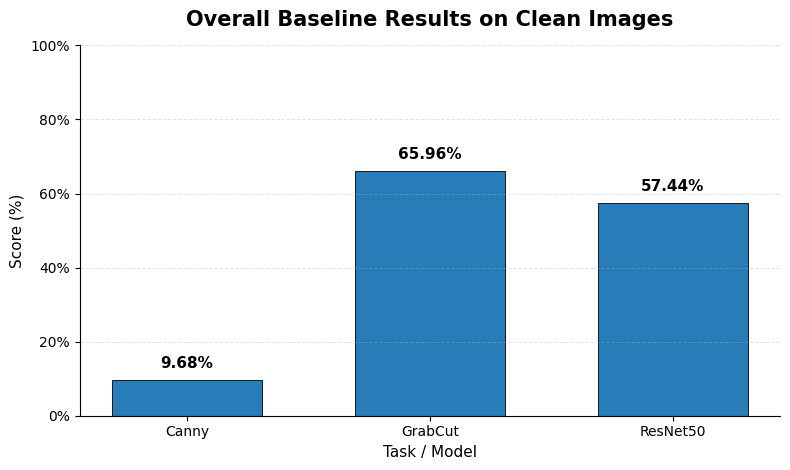

Graph saved to: /content/overall_baseline_clean.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

# Final results from the original Notebook 02
tasks = ["Canny", "GrabCut", "ResNet50"]

scores = [
    0.0968,  # Canny Mean Edge Density
    0.6596,  # GrabCut Mean Segmentation IoU
    0.5744   # ResNet50 Mean Jaccard
]

# Create a compact, presentation-friendly figure
fig, ax = plt.subplots(figsize=(8, 4.8))

bars = ax.bar(
    tasks,
    scores,
    width=0.62,
    color="#287DB8",
    edgecolor="black",
    linewidth=0.6
)

# Titles and axes
ax.set_title(
    "Overall Baseline Results on Clean Images",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Task / Model", fontsize=11)
ax.set_ylabel("Score (%)", fontsize=11)

ax.set_ylim(0, 1.0)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Display percentages above the bars
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.025,
        f"{score * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# Clean visual style
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

# Save the graph
output_path = Path("overall_baseline_clean.png")

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Graph saved to: {output_path.resolve()}")